In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/adronallen/Downloads/archive (2) 2/spreadspoke_scores.csv')
print(df.shape)
print(df.columns)


(14371, 17)
Index(['schedule_date', 'schedule_season', 'schedule_week', 'schedule_playoff',
       'team_home', 'score_home', 'score_away', 'team_away',
       'team_favorite_id', 'spread_favorite', 'over_under_line', 'stadium',
       'stadium_neutral', 'weather_temperature', 'weather_wind_mph',
       'weather_humidity', 'weather_detail'],
      dtype='object')


In [19]:
df.head()

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail
0,9/2/1966,1966,1,False,Miami Dolphins,14,23,Oakland Raiders,LVR,-14.0,NaN,Orange Bowl,False,83.0,6.0,71.0,NaN
1,9/3/1966,1966,1,False,Houston Oilers,45,7,Denver Broncos,TEN,-7.0,NaN,Rice Stadium,False,81.0,7.0,70.0,NaN
2,9/4/1966,1966,1,False,San Diego Chargers,27,7,Buffalo Bills,LAC,-4.0,NaN,Balboa Stadium,False,70.0,7.0,82.0,NaN
3,9/9/1966,1966,2,False,Miami Dolphins,14,19,New York Jets,NYJ,-16.0,NaN,Orange Bowl,False,82.0,11.0,78.0,NaN
4,9/10/1966,1966,1,False,Green Bay Packers,24,3,Baltimore Colts,GB,-1.0,NaN,Milwaukee County Stadium,False,64.0,8.0,62.0,NaN


In [20]:
# Checking how many values are missing from each column:
df.isnull().sum()

# Remoiving rows with missing values:
df = df.dropna(subset =['score_home', 'score_away', 'spread_favorite', 'over_under_line'])

#Filtering schedule_season to 2020-2025 seasons
print(df['schedule_season'].dtype)
season_20to25 = df[df['schedule_season'] > 2020].copy()


int64


**Did the Favorite Cover for the 21-25 season ?**

In [21]:
# How many games per season?
season_20to25['schedule_season'].value_counts().sort_index()

schedule_season
2021    285
2022    284
2023    285
2024    285
2025    285
Name: count, dtype: int64

In [22]:
# Calculating actual margin of victory
season_20to25 ['actual_margins'] = season_20to25 ['score_home'] - season_20to25 ['score_away']

# Computing Favorite's Margin
season_20to25 ['favorite_margin'] = np.where(
  season_20to25 ['team_favorite_id'] == season_20to25 ['team_home'],
   season_20to25 ['score_home']- season_20to25 ['score_away'],
    season_20to25 ['score_away']-season_20to25 ['score_home']
)

In [23]:
#Did the favorites cover ?
season_20to25 ['favorites_covered'] = (season_20to25 ['favorite_margin'] > season_20to25 ['spread_favorite'] )

#Calculating cover percentage
cover_rate = season_20to25 ['favorites_covered'].mean()
print(f"Favorite Cover Rate: {cover_rate}")

Favorite Cover Rate: 0.5948033707865169


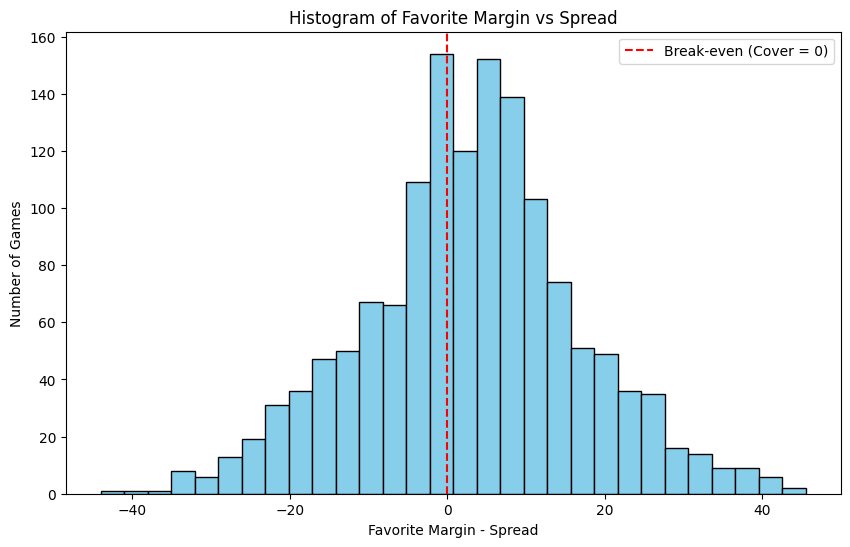

In [24]:
import matplotlib.pyplot as plt

# Calculate cover difference
season_20to25['cover_diff'] = season_20to25['favorite_margin'] - season_20to25['spread_favorite']

# plot histogram
plt.figure(figsize=(10,6))
plt.hist(season_20to25['cover_diff'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Break-even (Cover = 0)')
plt.title('Histogram of Favorite Margin vs Spread')
plt.xlabel('Favorite Margin - Spread')
plt.ylabel('Number of Games')
plt.legend()
plt.show()

In the 2020–2025 dataset, favorites covered the spread 59.5% of the time. This is slightly above the expected 50%, reflecting the fact that favorites win more often than underdogs. The result aligns with market efficiency expectations, given that sportsbooks adjust spreads to balance wagers.

**How accurate are Vegas over/under lines at predicting total points scored?**


In [25]:
# calculating total points
season_20to25['total_points'] = (
    season_20to25['score_away'] + season_20to25['score_home']
)

# convert over/under to numeric 
season_20to25['over_under_line'] = pd.to_numeric(
    season_20to25['over_under_line'],
    errors='coerce'
)

# Compute Over/Under Error
season_20to25['ou_error'] = (
    season_20to25['total_points'] - season_20to25['over_under_line']
)

In [26]:
season_20to25['over_under_line'].dtype

dtype('float64')

In [34]:
# How often do games go over ?
season_20to25['went_over'] = season_20to25['ou_error'] > 0
season_20to25['went_over'].mean()

# Mean Absolute Error
season_20to25['abs_ou_error'] = season_20to25['ou_error'].abs()
season_20to25['abs_ou_error'].mean()


np.float64(10.32759831460674)

On average, the game total differs from the Vegas O/U line by about 10.3 points

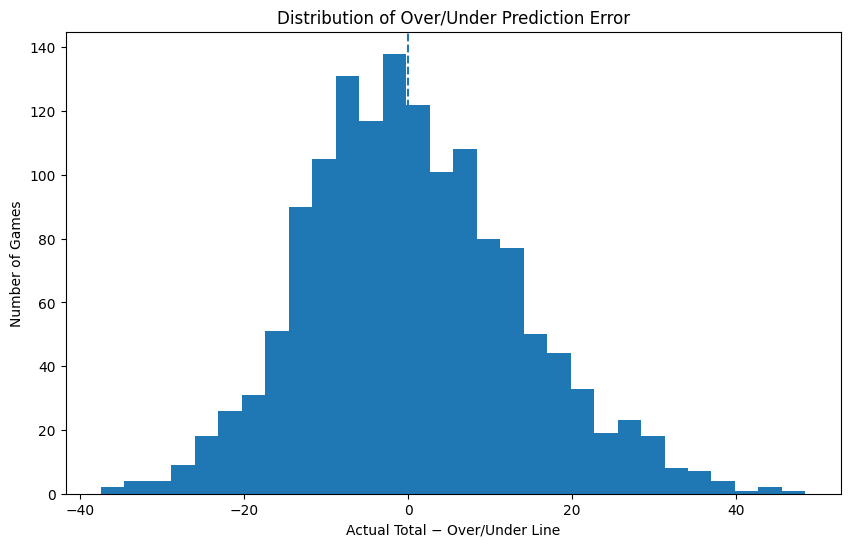

In [28]:
# Histogram of Over/Under
plt.figure(figsize=(10,6))
plt.hist(season_20to25['ou_error'], bins=30)
plt.axvline(0, linestyle='--')
plt.title('Distribution of Over/Under Prediction Error')
plt.xlabel('Actual Total − Over/Under Line')
plt.ylabel('Number of Games')
plt.savefig("ou_error_histogram.png", dpi=300, bbox_inches='tight')
plt.show()


The distribution of over/under prediction error is approximately symmetric and centered near zero, suggesting no consistent overestimation or underestimation of total points. This supports the hypothesis that over/under lines are efficiently priced.

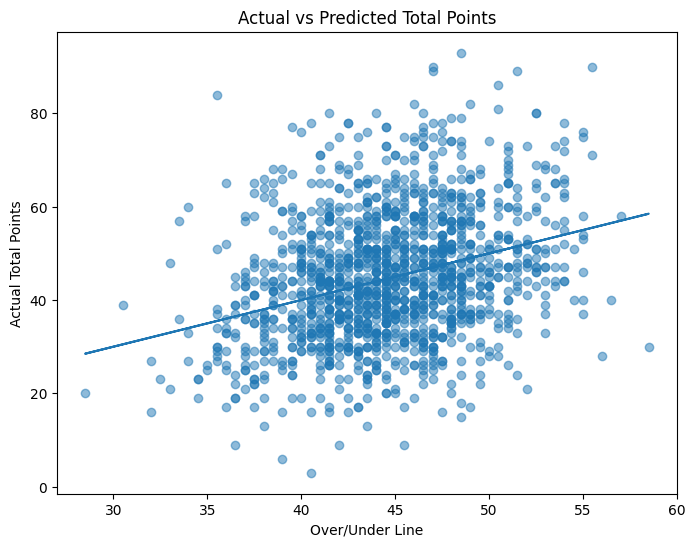

In [29]:
# Actual vs Predicted Total Points
plt.figure(figsize=(8,6))
plt.scatter(
    season_20to25['over_under_line'],
    season_20to25['total_points'],
    alpha=0.5
)
plt.plot(
    season_20to25['over_under_line'],
    season_20to25['over_under_line']
)
plt.xlabel('Over/Under Line')
plt.ylabel('Actual Total Points')
plt.title('Actual vs Predicted Total Points')
plt.savefig("actual_vs_predicted_totals.png", dpi=300, bbox_inches='tight')
plt.show()


The scatterplot shows a strong positive relationship between over/under lines and actual total points, indicating that sportsbooks correctly anticipate relative scoring environments. However, the wide dispersion around the diagonal line demonstrates substantial game-to-game variability, highlighting the inherent unpredictability of scoring outcomes.

In [30]:
# Coverage by season
coverage_by_year = season_20to25.groupby('schedule_season').agg(
    Coverage_Rate = ('favorites_covered', 'mean'),
    Games = ('favorites_covered', 'count'),
    Avg_Spread = ('spread_favorite', lambda x: x.abs().mean())
)

# Convert to percentage
coverage_by_year['Coverage_Rate'] *= 100

print("Coverage Rate by Season:")
print(coverage_by_year)


Coverage Rate by Season:
                 Coverage_Rate  Games  Avg_Spread
schedule_season                                  
2021                 60.701754    285    5.901754
2022                 60.915493    284    5.000000
2023                 56.491228    285    4.898246
2024                 58.947368    285    4.871930
2025                 60.350877    285    5.214035


Across the 2021–2025 seasons, favorites covered the spread between 56.5% and 60.9% of the time. Although coverage rates vary slightly by season, there is no consistent upward or downward trend, suggesting that sportsbook pricing remains relatively stable over time. Average spreads also remain consistent, further supporting the hypothesis of market efficiency.

In [33]:
years = coverage_by_year.index.astype(int)
rates = coverage_by_year['Coverage_Rate']

# Fit linear trend
slope, intercept = np.polyfit(years, rates, 1)

print("Trend analysis:")
print(f"Slope: {slope:.3f} percentage points per year")

Trend analysis:
Slope: -0.267 percentage points per year


A linear trend analysis shows a very small negative slope of −0.27 percentage points per year in favorite cover rates. Given the magnitude of this change, the result indicates no meaningful temporal trend, suggesting that sportsbook pricing efficiency has remained stable over the period studied.